# Ch4.모델 훈련

모델이 어떻게 작동하는지 잘 이해하고 있으면 적절한 모델, 올바른 훈련 알고리즘, 작업에 맞는 좋은 하이퍼파라미터를 빠르게 찾을 수 있다. 또한 디버깅이나 에러를 효율적으로 분석하는데 도움이 된다. 이 장에서 언급하는 대부분의 주제는 신경망을 이해하고 구축하고 훈련시키는 데 필수이다.

먼저 가장 간단한 모델인 선형 회귀부터 시작한다. 이 모델을 훈련시키는 두 가지 방법을 설명한다.

- 닫힌 형태의 방정식(Closed-form equation)을 사용하여 훈련 세트에 가장 잘 맞는 모델 파라미터, 즉 훈련 세트에 대해 비용 함수를 최소화하는 모델 파라미터를 직접 계산한다.  

- **경사하강법(Gradient Descent,GD)** 이라 불리는 반복적인 최적화 방식을 사용하여 모델 파라미터를 조금씩 바꾸면서 비용 함수를 최소화시킨다. 신경망에선 이를 변형한 Batch 경사하강법, Mini-batch 경사하강법, 확률적 경사하강법(SGD)를 사용한다.

결국에는 방정식과 경사하강법 모두 동일한 파라미터로 수렴하게 될 것이다.

그 다음엔 비선형 데이터셋에서 훈련시킬 수 있는 조금 더 복잡한 모델인 다항 회귀를 살펴본다. 다항 회귀는 선형 회귀보다 파라미터가 많아 훈련 데이터에 과대적합되기 더 쉬우므로, 학습 곡선(Learning curve)을 사용해 모델이 과대적합되는지 감지하는 방법도 살펴본다. 그런 다음 훈련 세트의 과대적합을 줄일 수 있는 규제 기법을 몇 가지 알아본다.

마지막으로 분류 작업에 자주 사용되는 로지스틱 회귀와 소프트맥스(Softmax) 회귀를 살펴본다.

---

## 4.1 선형 회귀

다음은 1장에서 살펴본 삶의 만족도에 대한 간단한 선형 회귀 모델이다.
$$
Satisfaction\ =\ \theta_0+\theta_1 \times GDP
$$


이 모델은 입력 변수인 1인당 GDP에 대한 선형 함수이다. $\theta_0$과 $\theta_1$이 모델 파라미터이다. $\theta$ 말고 $\beta$로 표현하기도 한다.

더 일반적으로 선형 모델은 다음과 같이 $n$개의 입력 변수의 가중치(계수) 합과 절편(또는 편향)이라는 상수를 더해 예측을 만든다.
$$
\hat{y}=\theta_0+\theta_1x_1+\theta_2x_2+\cdots +\theta_n x_n
$$

이 식은 다음과 같이 벡터 형태로 더 간단하게 쓸 수 있다.
$$
\hat{y}=h_{\theta}(\boldsymbol{X})=\Theta\boldsymbol{X}
$$

<center>

| Notations | 설명 |
|:---------:|:---:|
|$h_{\theta}$|모델 파라미터 $\Theta$를 사용한 가설 함수 |
|$\Theta$    |절편 $\theta_0$와 나머지 변수의 가중치를 담은 파라미터 벡터 |
|$\boldsymbol{X}$| $x_0$에서 $x_n$까지 담은 샘플의 특성 벡터 ($x_0$는 항상 1)|
|$\Theta\boldsymbol{X}$| 벡터 $\Theta$와 $\boldsymbol{X}$의 dot product |

</center>

머신러닝에서는 종종 벡터를 하나의 열을 가진 2D 배열인 **열 벡터**로 나타낸다. $\Theta$와 $\boldsymbol{X}$가 열 벡터라면 예측은 $\hat{y}=\Theta^T\boldsymbol{X}$이다. 물론 예측 결과는 같다.

이제 모델을 훈련시켜본다. 먼저 모델이 훈련 데이터에 얼마나 잘 들어맞는지 측정해야 한다. 2장에서 언급했듯이, 회귀에 가장 널리 사용되는 성능 측정 지표는 평균 제곱근 오차 $RMSE$이다. 그러므로 선형 회귀모델을 훈련시키려면 $RMSE$를 최소화하는 $\Theta$를 찾아야 한다. 실제로는 $RMSE$보단 $MSE$를 최소화하는 것이 같은 결과를 내면서 더 간단하다.

훈련 세트 $\boldsymbol{X}$에 대한 선형 회귀 가설 $h_{\theta}$의 $MSE$는 다음과 같이 계산한다.
$$
MSE(\Theta) = \frac{1}{m}\sum_{i=1}^{m}(\Theta^TX^{(i)}-y^{(i)})^2
$$

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● Caution</strong><br>
    학습 알고리즘은 종종 최종 모델을 평가하는 데 사용되는 성능 지표와 다른 손실 함수를 훈련 중에 최적화한다. 이는 일반적으로 해당 함수가 최적화하기 더 쉽거나 훈련 중에만 필요한 추가 항이 있기 때문이다. 예를 들어 분류기는 종종 로그 손실과 같은 비용 함수를 사용하여 학습되지만 정밀도와 재현율을 사용하여 평가된다. 로그 손실은 최소화하기 쉬우며, 일반적으로 로그 손실의 최소화로 정밀도와 재현율이 향상된다.
</div>

### 정규 방정식

비용 함수를 최소화하는 $\Theta$ 값을 찾기 위해 결과를 바로 얻을 수 있는 공식이 있다. 이를 **정규 방정식(Normal equation)** 이라고 한다.
$$
\hat{\Theta}=(X^TX)^{-1}X^TY
$$

<center>

| Notations | 설명 |
|:--------: |:---:|
| $\hat{\Theta}$ | 비용함수를 최소화하는 $\Theta$ |
|        $Y$     | $y^{(1)}$부터 $y^{(m)}$까지 포함하는 타겟 벡터 |

</center>

이 공식을 테스트하기 위해 선형처럼 보이는 데이터를 생성해본다.

In [2]:
import numpy as np

np.random.seed(42)
m = 100
X = 2 * np.random.rand(m,1)
y = 4 + 3 * X + np.random.randn(m,1)

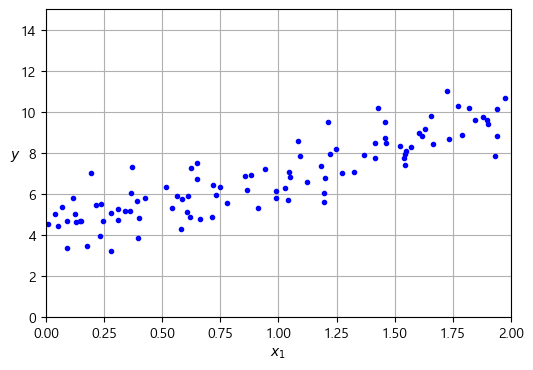

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')  
plt.rcParams['axes.unicode_minus'] = False 


plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

이제 정규 방정식으로 사용해 $\hat{\Theta}$를 게산해본다. 넘파이 선형대수 모듈 `np.linalg`에 있는 `inv()` 함수를 사용해 역행렬을 계산하고 `dot()` 메서드를 사용해 행렬 곱을 한다.

In [7]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)    ##각 샘플에 X_0 = 1을 추가한다.
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

<div style="border: 2px solid rgb(233, 224, 222); padding: 10px; background-color: rgb(233, 224, 222); margin: 10px 0;">
    <strong style="font-weight: bold;">● @ 연산자</strong><br>
    @ 연산자는 행렬 곱셈을 수행한다. A와 B가 넘파이 배열인 경우, A @ B는 <code>np.matmul(A,B)</code>와 동일하다. 텐서플로, 파이토치 등 많은 라이브러리에서도 @ 연산자를 지원한다. 순수 파이썬 배열에는 @ 연사자를 사용할 수 없다.
</div>

데이터를 생성하기 위해 사용된 함수는 $y=4+3x_1+Gaussian Noise$이다. 정규 방정식으로 계산한 값을 확인해본다.

In [8]:
print(theta_best)

[[4.21509616]
 [2.77011339]]


매우 비슷하지만 잡음 때문에 원래 함수의 파라미터를 정확하게 재현하지 못했다. 데이터셋이 작고 잡음이 많을수록 정확한 값을 얻기 힘들다. $\hat{\Theta}$를 사용해 예측을 해본다.

In [11]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

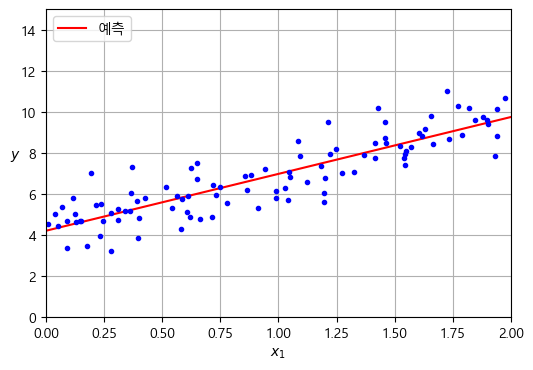

In [13]:
plt.figure(figsize=(6, 4))  
plt.plot(X_new, y_predict, "r-", label="예측")
plt.plot(X, y, "b.")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
plt.show()

사이킷런에서 선형 회귀를 수행하는 것은 매우 간단하다.

In [16]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y);
print(lin_reg.intercept_,lin_reg.coef_)
print(lin_reg.predict(X_new))

[4.21509616] [[2.77011339]]
[[4.21509616]
 [9.75532293]]


사이킷런은 변수의 가중치 `coef_`와 절편 `intercept_`를 분리하여 저장한다. `LinearRegression` 클래스는 `scipy.linalg.lstsq()` 함수를 기반으로 한다. 다음과 같이 이 함수를 직접 호출할 수 있다.

In [18]:
theta_best_svd, residuals, rank, s =np.linalg.lstsq(X_b,y,rcond=1e-6)
print(theta_best_svd)

[[4.21509616]
 [2.77011339]]


이 함수는 $\hat{\Theta}=X^{+}\boldsymbol{y}$를 계산한다. 여기에서 $X^{+}$는 $X$의 **무어-펜로즈 유사역행렬(Pseudo-inverse)** 이다. `np.linalg.pinv()` 함수를 사용해 유사역행렬을 직접 구할 수 있다.

In [19]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체는 **특이값 분해(Singular Value Decomposition,SVD)** 라 부르는 표준 행렬 분해 기법을 사용해 계산된다. SVD는 훈련 세트 행렬 $X$를 3개의 행렬 곱셈 $V\Sigma^{+}U^{T}$로 분해한다. `np.linalg.svd()` 함수를 사용하여 특이값 분해를 수행할 수 있다.

유사역행렬은 $X^{+}=V\Sigma^{+}U^{T}$로 계산된다. $\Sigma^{+}$를 계산하기 위해 알고리즘이 먼저 $\Sigma$를 구한 다음 어떤 낮은 임계값보다 작은 모든 수를 0으로 바꾼다. 그 다음 0이 아닌 모든 값을 역수로 치환한다. 마지막으로 만들어진 행렬을 전치한다. 정규 방정식을 계산하는 것보다 이 방식이 훨씬 효율적이다. 또한 극단적인 경우도 처리할 수 있다.  
실제로 $m \lt n$이거나 어떤 변수가 중복되어 행렬 $X^{T}X$의 역행렬이 없다면 ($Det(X)$가 0이거나 거의 0인 경우) 정규 방정식이 작동하지 않는다. 하지만 유사역행렬은 항상 구할 수 있다.

### 계산복잡도

정규 방정식은 $(n+1) \times (n+1)$ 크기의 $X^{T}X$의 행렬을 계산한다($n$은 변수의 수). 역행렬을 계산하는 계산 복잡도는 일반적으로 $O(n^{2.4})$에서 $O(n{3})$ 사이이며, 구현 방법에 따라 차이가 존재한다. 이는 변수의 수가 두 배로 늘어나면 계산 시간이 대략 $2^{2.4}=5.3$에서 $2^3=8$배로 증가한다는 의미이다.

사이킷런의 `LinearRegression` 클래스가 사용하는 SVD 방법은 약 $O(n^2)$이다. 변수의 개수가 두 배로 늘어나면 계산 시간은 대략 4배가 된다.

또한 정규 방정식이나 다른 알고리즘으로 학습된 선형 회귀 모델은 예측이 매우 빠르다. 예측 계산 복잡도는 샘플 수와 변수의 수에 선형적이다. 다시 말해 예측하려는 샘플이나 변수가 두 배로 증가하면 걸리는 시간도 거의 두 배 증가한다.

---

## 4.2 경사하강법